<a href="https://colab.research.google.com/github/vituhaa/Healthy-Posture/blob/project/EfficientNetB0_experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Работа с EfficientNetB0

EfficientNetB0 (Transfer Learning): This model uses a pre-trained EfficientNetB0 backbone with its weights frozen. A custom classification head—consisting of a Global Average Pooling layer, a Dense layer, and a Dropout layer—was added on top for the specific task of posture classification.

Optimizer: Adam

Loss Function: Binary Crossentropy

Epochs: 15

Data Augmentation: To improve generalization, the training data was augmented
with random horizontal flips, rotations, and zooms.

Both models were evaluated on an unseen test set of 27 images. While they achieved the same overall accuracy, their performance characteristics on a per-class basis were notably different.

Transfer learning tutorial - https://www.tensorflow.org/tutorials/images/transfer_learning

In [7]:
import shutil
import os
import cv2
import numpy as np
import tensorflow as tf
from matplotlib import pyplot as plt
import tensorflow.keras as keras
from tensorflow.keras.applications import EfficientNetB0
from keras import layers
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

In [2]:
from google.colab import drive
drive.mount('content/')

Mounted at content/


In [ ]:
# # операция проведена один раз для копирования файлов из старого датасета в новый
# from_folder = '/content/content/MyDrive/датасет для курсовой работы, 3 курс/MoveNet_MLP_dataset'
# new_folder = '/content/content/MyDrive/датасет для курсовой работы, 3 курс/EfficientNetB0_dataset'

# folders_names = {
#     'bend_over': 'bad',
#     'body_left': 'bad',
#     'body_right': 'bad',
#     'head_left': 'bad',
#     'head_right': 'bad',
#     'too_close': 'bad',
#     'tilt_back': 'bad',
#     'correct': 'good'
# }

# for prev_category, new_category in folders_names.items():
#   prev_path = os.path.join(from_folder, prev_category)
#   new_path = os.path.join(new_folder, new_category)
#   os.makedirs(new_path, exist_ok=True)

#   for photo in os.listdir(prev_path):
#     old_photo = os.path.join(prev_path, photo)
#     new_photo = os.path.join(new_path, photo)
#     if os.path.exists(new_photo):
#       photo_name, photo_type = os.path.splitext(new_photo)
#       count = 1
#       while (os.path.exists(os.path.join(new_path, f"{photo_name}_{count}{photo_type}"))):
#         count += 1
#       new_photo = os.path.join(new_path, f"{photo_name}_{count}{photo_type}")
#     shutil.copy2(old_photo, new_photo)


In [3]:
bad_path = '/content/content/MyDrive/датасет для курсовой работы, 3 курс/EfficientNetB0_dataset/bad'
good_path = '/content/content/MyDrive/датасет для курсовой работы, 3 курс/EfficientNetB0_dataset/good'
# print(len(os.listdir(good_path)) + len(os.listdir(bad_path)))

In [17]:
# preprocess
categories = ['good', 'bad']

X = []
y = []

def preprocess_photos(image, label):
  # img = cv2.imread(path)
  # img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
  # img = cv2.resize(img, photo_size)
  image = tf.cast(image, np.float32) / 255.0
  return image, label

for x in os.listdir(bad_path):
  X.append(os.path.join(bad_path, x))
  y.append(1) # 1 - нарушения есть

for x in os.listdir(good_path):
  X.append(os.path.join(good_path, x))
  y.append(0) # 0 - нарушений нет

augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2)
])

In [6]:
print(len(X))
print(len(y))

1812
1812


In [18]:
def make_model():
  picture_size = 224
  inputs = layers.Input(shape=(picture_size, picture_size, 3))
  ### ?
  x = augmentation(inputs)
  ###
  base_model = EfficientNetB0(include_top=False, input_tensor=inputs, weights='imagenet')

  base_model.trainable = False

  x = layers.GlobalAveragePooling2D()(base_model.output)
  x = layers.Dropout(0.2)(x)
  outputs = layers.Dense(1, activation="sigmoid")(x)
  # print(outputs)
  model = keras.Model(inputs, outputs)
  optimizer = keras.optimizers.Adam(learning_rate=0.0001)
  loss = keras.losses.BinaryCrossentropy(from_logits=False)
  model.compile(optimizer=optimizer, loss=loss, metrics=["accuracy"])
  return model

In [11]:
ds_dir = '/content/content/MyDrive/датасет для курсовой работы, 3 курс/EfficientNetB0_dataset/'

train_ds = tf.keras.utils.image_dataset_from_directory(
    ds_dir,
    validation_split=0.2,
    subset='training',
    seed=123,
    image_size=(224, 224),
    batch_size=32
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    ds_dir,
    validation_split=0.2,
    subset='validation',
    seed=123,
    image_size=(224, 224),
    batch_size=32
)

Found 1812 files belonging to 2 classes.
Using 1450 files for training.
Found 1812 files belonging to 2 classes.
Using 362 files for validation.


In [19]:
train_ds.map(preprocess_photos)
val_ds.map(preprocess_photos)

<_MapDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [20]:
model = make_model()
history = model.fit(train_ds,
                    validation_data=val_ds,
                    epochs=15,
                    batch_size=32,
                    verbose=1)

Epoch 1/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 300s 6s/step - accuracy: 0.6883 - loss: 0.6054 - val_accuracy: 0.8674 - val_loss: 0.4971
Epoch 2/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 190s 3s/step - accuracy: 0.8490 - loss: 0.4720 - val_accuracy: 0.8729 - val_loss: 0.4122
Epoch 3/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 156s 3s/step - accuracy: 0.8600 - loss: 0.4128 - val_accuracy: 0.8729 - val_loss: 0.3779
Epoch 4/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 164s 4s/step - accuracy: 0.8593 - loss: 0.3880 - val_accuracy: 0.8729 - val_loss: 0.3584
Epoch 5/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 179s 3s/step - accuracy: 0.8593 - loss: 0.3777 - val_accuracy: 0.8729 - val_loss: 0.3436
Epoch 6/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 142s 3s/step - accuracy: 0.8593 - loss: 0.3653 - val_accuracy: 0.8729 - val_loss: 0.3305
Epoch 7/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 145s 3s/step - accuracy: 0.8593 - loss: 0.3506 - val_accuracy: 0.8729 - val_loss: 0.3185
Epoch 8/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 164s 4s/step - accuracy: 0.8593 - loss: 0.3415 - val_accuracy: 0.8729 - v

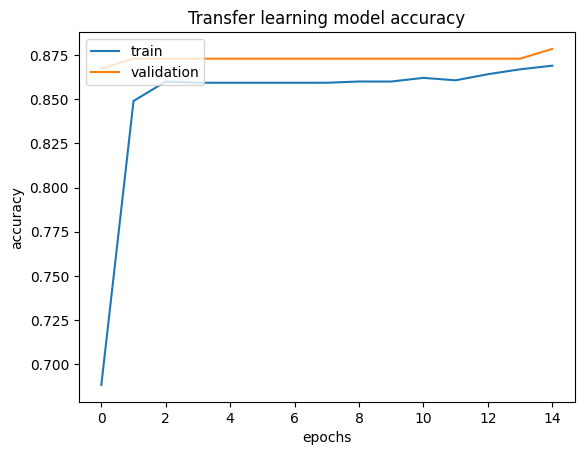

In [21]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.title("Transfer learning model accuracy")
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.legend(["train", "validation"], loc="upper left")
plt.show()

In [28]:
model.save('tl_EfficientNetB0.h5')

In [29]:
model.save('tl_EfficientNetB0.keras')

Custom CNN: A lightweight Convolutional Neural Network built from scratch. The architecture consists of three convolutional blocks with MaxPooling, followed by a dense classifier with a Dropout layer for regularization.

In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Dropout, Flatten, BatchNormalization

filers_size = (3, 3)

custom_cnn = Sequential([
    Conv2D(32, filers_size, activation='relu', padding='same', input_shape=(224, 224, 3)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(64, filers_size, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Conv2D(128, filers_size, activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # Conv2D(256, filers_size, activation='relu', padding='same'),
    # BatchNormalization(),

    Flatten(),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

optimizer = keras.optimizers.Adam(learning_rate=0.0001)
loss = keras.losses.BinaryCrossentropy(from_logits=False)

custom_cnn.compile(
    optimizer=optimizer,
    loss=loss,
    metrics=["accuracy"]
)

custom_cnn.fit(
    train_ds,
    epochs=5,
    validation_data=val_ds
)

Epoch 1/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 288s 6s/step - accuracy: 0.8676 - loss: 0.7303 - val_accuracy: 0.9337 - val_loss: 0.2355
Epoch 2/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 326s 6s/step - accuracy: 0.9455 - loss: 0.1747 - val_accuracy: 0.9641 - val_loss: 0.1980
Epoch 3/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 321s 6s/step - accuracy: 0.9579 - loss: 0.1232 - val_accuracy: 0.9779 - val_loss: 0.0880
Epoch 4/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 320s 6s/step - accuracy: 0.9697 - loss: 0.1215 - val_accuracy: 0.9890 - val_loss: 0.0309
Epoch 5/5
46/46 ━━━━━━━━━━━━━━━━━━━━ 327s 6s/step - accuracy: 0.9690 - loss: 0.1159 - val_accuracy: 0.9917 - val_loss: 0.0283


In [25]:
custom_cnn.save('custom_cnn.h5')

In [26]:
custom_cnn.save('custom_cnn.keras')

Проверка обеих моделей на тестовом датасете из 80 фотографий: